# ServLink — Search Query Classifier: Training & Evaluation

Trains a TF-IDF + Logistic Regression model that maps a free-text search query to one of ServLink's 8 service categories, replacing the naive keyword matching (`if query.includes("electric")`) previously used on the search page.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_colwidth", 100)

## 1. Load the dataset

1,012 synthetic labeled queries, generated by `generate_data.py` from phrase templates + vocabulary (locations, issues, item names, synonyms). There's no real user query log yet since ServLink hasn't launched, so this approximates realistic phrasing — including indirect, symptom-based descriptions, not just category keywords.

In [2]:
df = pd.read_csv("data/queries.csv")
print(f"Total rows: {len(df)}")
print(f"Categories: {df['category'].nunique()}")
df.sample(8, random_state=1)

Total rows: 1012
Categories: 8


,text,category
951,need accommodation in Wattala for a family,house-rental
618,need carpenter for a leaking geyser,carpenter
293,need to find a place to stay in Galle,house-rental
507,this place is grimy after the tenants left need it spotless before we move in,cleaner
999,need someone to install extra sockets,carpenter
248,need cleaning service before moving out Nugegoda,cleaner
720,landlord looking to lease out apartment in Kotte,house-rental
912,family looking to rent 4 bedroom house Kelaniya,house-rental


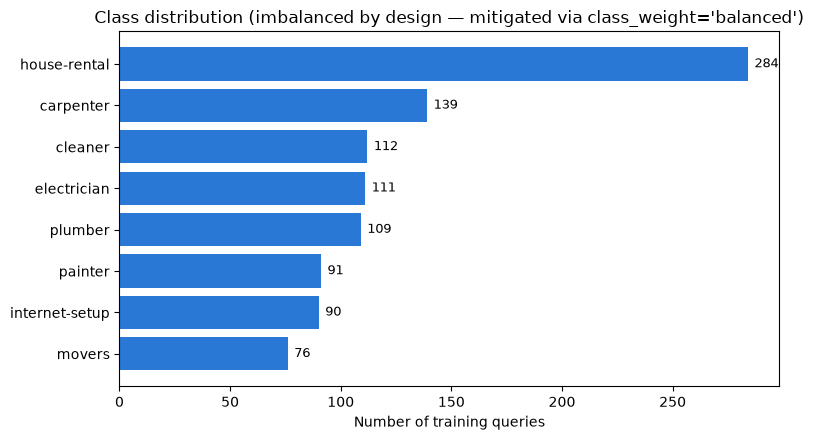

In [3]:
counts = df["category"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(counts.index[::-1], counts.values[::-1], color="#2a78d6")
ax.set_xlabel("Number of training queries")
ax.set_title("Class distribution (imbalanced by design — mitigated via class_weight='balanced')")
for i, v in enumerate(counts.values[::-1]):
    ax.text(v + 3, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 2. Train / test split

80/20 stratified split (each category proportionally represented in both sets), fixed random seed for reproducibility.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["category"],
    test_size=0.2, random_state=42, stratify=df["category"],
)
print(f"Train: {len(X_train)} rows   Test: {len(X_test)} rows")

Train: 809 rows   Test: 203 rows


## 3. Train the model

**TF-IDF Vectorizer** (1–2 word n-grams) → **Logistic Regression** (`class_weight="balanced"` to handle the uneven category sizes above), chained into one scikit-learn `Pipeline`.

In [5]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1, sublinear_tf=True)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
])
pipeline.fit(X_train, y_train)
print("Model trained.")

Model trained.


D:\BSE\DP\servlink\backend\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 4. Evaluate on the held-out test set

In [6]:
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"TEST ACCURACY: {accuracy:.2%}\n")
print(classification_report(y_test, y_pred, zero_division=0))

TEST ACCURACY: 92.61%

                precision    recall  f1-score   support

     carpenter       0.92      0.82      0.87        28
       cleaner       0.96      1.00      0.98        23
   electrician       0.80      0.73      0.76        22
  house-rental       1.00      1.00      1.00        57
internet-setup       0.89      0.94      0.92        18
        movers       1.00      0.93      0.97        15
       painter       1.00      1.00      1.00        18
       plumber       0.77      0.91      0.83        22

      accuracy                           0.93       203
     macro avg       0.92      0.92      0.92       203
  weighted avg       0.93      0.93      0.93       203



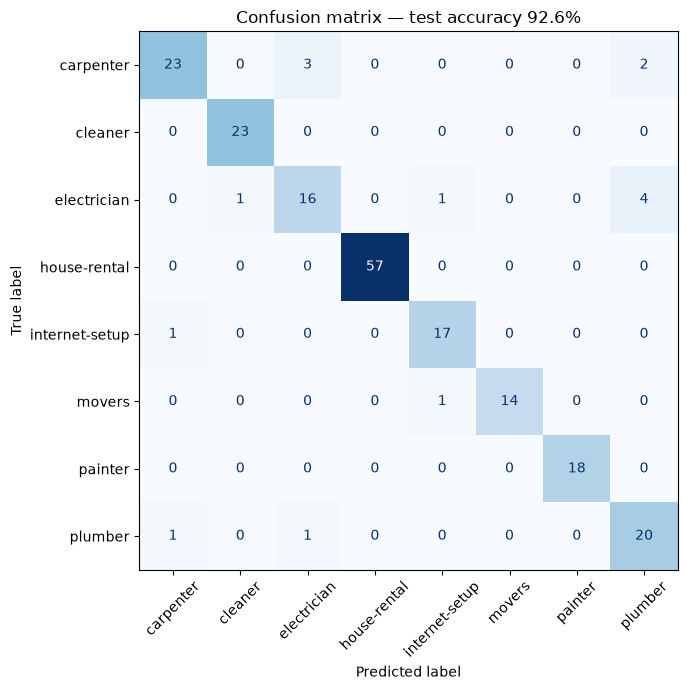

In [7]:
labels = sorted(df["category"].unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
ax.set_title(f"Confusion matrix — test accuracy {accuracy:.1%}")
plt.tight_layout()
plt.show()

## 5. Generalization check: phrasing never seen in training

The test set above was split from the *same templates* as training, so its accuracy partly reflects recognizing template structure rather than true generalization. To test that honestly, 26 sentences were hand-written from scratch — different vocabulary, indirect/symptom-based descriptions, no template reuse — and scored the same way.

In [8]:
novel_queries = [
    ("the switch board is sparking whenever it rains", "electrician"),
    ("none of the plug points in the bedroom are working", "electrician"),
    ("my inverter battery won't charge anymore", "electrician"),
    ("there's a burning smell coming from behind the TV unit", "electrician"),
    ("water is dripping from the ceiling below the bathroom", "plumber"),
    ("the toilet cistern overflows every time it's flushed", "plumber"),
    ("kitchen sink drain is completely clogged with grease", "plumber"),
    ("no hot water at all this morning", "plumber"),
    ("I'm moving from my rented flat to a new place next week and need a van", "movers"),
    ("relocating the whole office to a bigger building next month", "movers"),
    ("need help carrying a fridge and washing machine to the new place", "movers"),
    ("this place is filthy after the tenants left, need it spotless before we move in", "cleaner"),
    ("the curtains and sofa smell musty and need a proper wash", "cleaner"),
    ("carpets are stained after the party last week", "cleaner"),
    ("the hinges on my almirah are loose and one shelf collapsed", "carpenter"),
    ("dining table wobbles because a leg is cracked", "carpenter"),
    ("need someone to build built-in shelves for the study room", "carpenter"),
    ("my zoom calls keep freezing, think the connection speed is bad", "internet-setup"),
    ("the wifi doesn't reach the upstairs bedrooms at all", "internet-setup"),
    ("streaming keeps buffering even with a strong signal shown", "internet-setup"),
    ("the outside walls look faded and patchy, want a fresh coat", "painter"),
    ("ceiling has damp stains and the paint is peeling off", "painter"),
    ("want to change the living room colour to something brighter", "painter"),
    ("newly married couple looking for a small place close to the city center", "house-rental"),
    ("need a fully furnished flat for a short term stay", "house-rental"),
    ("single professional looking for a room close to the office", "house-rental"),
]

rows = []
for text, expected in novel_queries:
    pred = pipeline.predict([text])[0]
    conf = pipeline.predict_proba([text]).max()
    rows.append({"query": text, "expected": expected, "predicted": pred, "confidence": round(conf, 2), "correct": pred == expected})

novel_df = pd.DataFrame(rows)
novel_accuracy = novel_df["correct"].mean()
print(f"NOVEL-PHRASING ACCURACY: {novel_accuracy:.1%}  ({novel_df['correct'].sum()}/{len(novel_df)})\n")

def highlight(row):
    color = "#d4f4dd" if row["correct"] else "#fbdada"
    return [f"background-color: {color}"] * len(row)

novel_df.style.apply(highlight, axis=1)

NOVEL-PHRASING ACCURACY: 73.1%  (19/26)



,query,expected,predicted,confidence,correct
0,the switch board is sparking whenever it rains,electrician,electrician,0.240000,True
1,none of the plug points in the bedroom are working,electrician,plumber,0.310000,False
2,my inverter battery won't charge anymore,electrician,carpenter,0.200000,False
3,there's a burning smell coming from behind the TV unit,electrician,electrician,0.240000,True
4,water is dripping from the ceiling below the bathroom,plumber,plumber,0.620000,True
5,the toilet cistern overflows every time it's flushed,plumber,plumber,0.290000,True
6,kitchen sink drain is completely clogged with grease,plumber,plumber,0.400000,True
7,no hot water at all this morning,plumber,electrician,0.240000,False
8,I'm moving from my rented flat to a new place next week and need a van,movers,movers,0.330000,True
9,relocating the whole office to a bigger building next month,movers,movers,0.160000,True


## 6. Try it yourself

Edit `test_query` below and re-run the cell to see a live prediction.

In [9]:
test_query = "my toilet keeps overflowing"  # <-- edit this and re-run

proba = pipeline.predict_proba([test_query])[0]
ranked = sorted(zip(pipeline.named_steps["clf"].classes_, proba), key=lambda x: -x[1])

print(f'"{test_query}"\n')
for label, p in ranked:
    bar = "#" * int(p * 40)
    print(f"  {label:15s} {p:.2%}  {bar}")

"my toilet keeps overflowing"

  plumber         21.16%  ########
  electrician     18.10%  #######
  internet-setup  13.99%  #####
  carpenter       12.42%  ####
  house-rental    9.91%  ###
  cleaner         9.11%  ###
  painter         8.16%  ###
  movers          7.15%  ##


## Limitations & next steps

- **Bag-of-words can't recognize unseen synonyms.** TF-IDF only reacts to tokens it saw in training — words like "almirah", "musty", or "colour" have no learned association, which explains most of the gap between the two accuracy numbers above.
- **Training data is entirely synthetic** — no real user query log exists yet since ServLink hasn't launched.
- **Electrician ↔ plumber confusion** concentrates around water-heater/hot-water phrasing that's genuinely ambiguous even to a person.
- **Next step:** swap TF-IDF for pretrained word embeddings to close the synonym gap without needing more labeled data; once real users start searching, log real queries (with consent) to replace synthetic data.

This notebook mirrors `train.py` and `smoke_test.py`, which are what actually produce `model/classifier.joblib` and `model/metrics.json` used by the live app (`backend/app/main.py` → the Search page's "Model info" panel).